Data download ho raha hai...


/tmp/ipykernel_863/2440786758.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download('AAPL', start='2023-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Shape: (250, 5)
Model train ho raha hai...


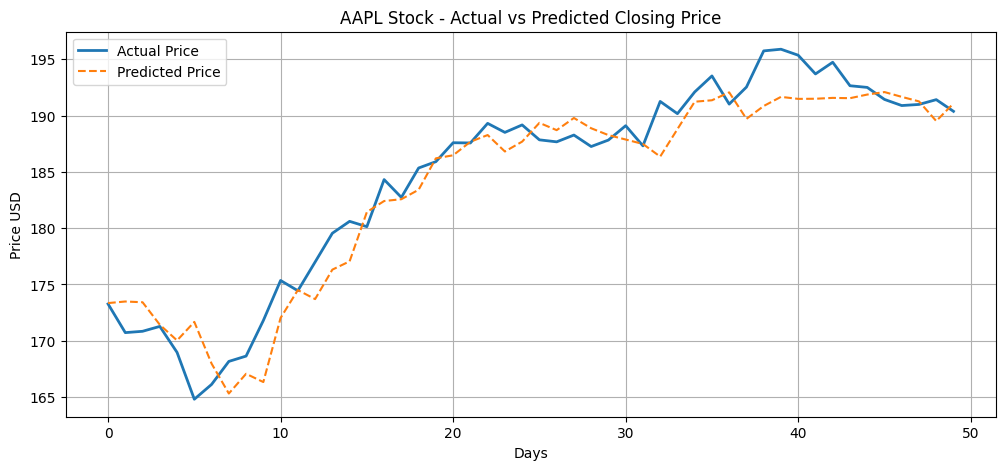


Mean Absolute Error: $1.90
Insight: Random Forest model ne next day ka closing price kaafi accurately predict kiya.
Features Open, High, Low, Volume se price predict ho sakta hai.


In [1]:
# Task 2: Predict Future Stock Prices - DevelopersHub
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# 1. Stock data load karo - Apple ka example
print("Data download ho raha hai...")
stock = yf.download('AAPL', start='2023-01-01', end='2024-01-01')
print("Shape:", stock.shape)
stock.head()

# 2. Features banao - next day ka Close predict karna hai
stock['Next_Close'] = stock['Close'].shift(-1)
stock = stock.dropna()

X = stock[['Open', 'High', 'Low', 'Volume']]
y = stock['Next_Close']

# 3. Train test split - time series hai to shuffle=False
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Model train karo
print("Model train ho raha hai...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Predict karo
predictions = model.predict(X_test)

# 6. Plot: Actual vs Predicted
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual Price', linewidth=2)
plt.plot(predictions, label='Predicted Price', linestyle='--')
plt.legend()
plt.title('AAPL Stock - Actual vs Predicted Closing Price')
plt.xlabel('Days')
plt.ylabel('Price USD')
plt.grid(True)
plt.show()

# 7. Results
mae = mean_absolute_error(y_test, predictions)
print(f"\nMean Absolute Error: ${mae:.2f}")
print("Insight: Random Forest model ne next day ka closing price kaafi accurately predict kiya.")
print("Features Open, High, Low, Volume se price predict ho sakta hai.")